# Employee Attrition Analytics

## Module 9: Model Explainability

### Objective

Understand why the machine learning model predicts employee attrition and translate model results into meaningful business insights.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

## Load ML-Ready Dataset

In [2]:
df = pd.read_csv("../data/processed/employee_attrition_ml_ready.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 52)


,Age,Gender,Experience,Salary,Performance_Score,Job_Satisfaction,Overtime,Work_Hours,Remote_Work,Training_Hours,...,Salary_Band_Medium,Salary_Band_High,Salary_Band_Very High,Experience_Band_Junior,Experience_Band_Mid Level,Experience_Band_Senior,Satisfaction_Category_Medium,Satisfaction_Category_High,Performance_Category_Average,Performance_Category_High
0,40.0,0,3,94113.0,5,6.0,1,46,0,70,...,1,0,0,1,0,0,1,0,0,1
1,39.0,1,2,54224.0,4,9.0,0,36,0,33,...,0,0,0,0,0,0,0,1,0,1
2,49.0,0,25,166749.0,2,6.0,0,48,1,75,...,0,1,0,0,0,1,1,0,0,0
3,54.0,1,26,196590.0,5,4.0,1,51,1,64,...,0,0,1,0,0,1,0,0,0,1
4,41.0,1,18,231764.0,3,8.0,1,40,1,15,...,0,0,1,0,0,1,0,1,1,0


## Prepare Features and Target

In [3]:
X = df.drop(columns=["Attrition", "Attrition_Target"])

y = df["Attrition_Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 50)
Target shape: (1000,)


## Validate Feature Data Types

In [4]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns

print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
['Promotion_Last_5Yrs']


In [5]:
X["Promotion_Last_5Yrs"] = X["Promotion_Last_5Yrs"].map({"No": 0, "Yes": 1})

print(X["Promotion_Last_5Yrs"].value_counts())

Promotion_Last_5Yrs
0    794
1    206
Name: count, dtype: int64


In [6]:
non_numeric_columns = X.select_dtypes(exclude=np.number).columns

print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
[]


## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 50)
Testing data: (200, 50)


## Train Final Random Forest

In [8]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
)

final_model.fit(X_train, y_train)

print("Final Random Forest trained successfully.")

Final Random Forest trained successfully.


## Evaluate Final Model

In [9]:
y_pred = final_model.predict(X_test)

y_prob = final_model.predict_proba(X_test)[:, 1]

In [10]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, zero_division=0)

recall = recall_score(y_test, y_pred, zero_division=0)

f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_prob)

print("Final Random Forest")
print("=" * 35)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Final Random Forest
Accuracy : 0.935
Precision: 0.7619
Recall   : 0.6667
F1 Score : 0.7111
ROC-AUC  : 0.9813


## Random Forest Feature Importance

Feature importance indicates which features contributed most to the model's predictions.

In [11]:
feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": final_model.feature_importances_}
)

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
5,Job_Satisfaction,0.369765
46,Satisfaction_Category_Medium,0.087381
47,Satisfaction_Category_High,0.068819
6,Overtime,0.066617
16,Salary_Per_Experience,0.033952
9,Training_Hours,0.031390
14,Years_At_Company,0.030263
3,Salary,0.026028
17,Workload_Score,0.025272
0,Age,0.024627


## Top 20 Feature Importances

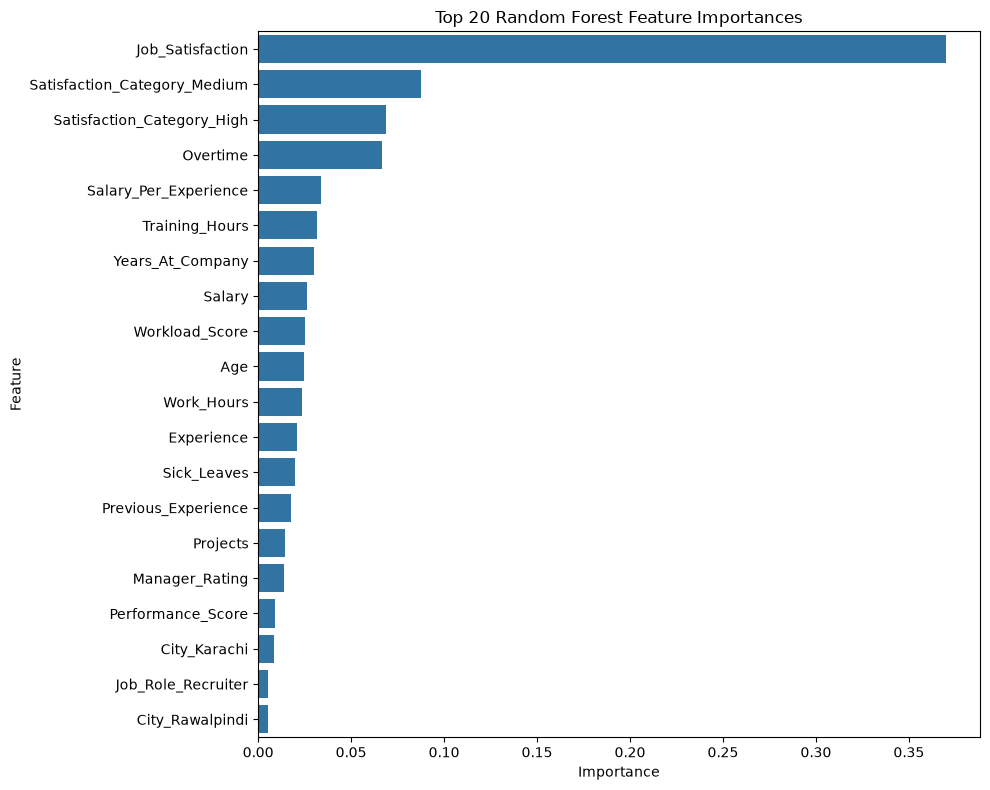

In [12]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(data=top_features, x="Importance", y="Feature")

plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Permutation Importance

Permutation importance measures how much model performance depends on each feature by evaluating the effect of randomly shuffling that feature.

In [13]:
permutation = permutation_importance(
    final_model, X_test, y_test, scoring="f1", n_repeats=10, random_state=42, n_jobs=-1
)

permutation_importance_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance_Mean": permutation.importances_mean,
        "Importance_Std": permutation.importances_std,
    }
)

permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance_Mean", ascending=False
)

permutation_importance_df.head(20)

,Feature,Importance_Mean,Importance_Std
5,Job_Satisfaction,0.589969,0.082276
6,Overtime,0.286928,0.098805
46,Satisfaction_Category_Medium,0.251999,0.127664
47,Satisfaction_Category_High,0.182477,0.090390
0,Age,0.006399,0.024210
12,Manager_Rating,0.003184,0.020107
43,Experience_Band_Junior,0.000000,0.000000
45,Experience_Band_Senior,0.000000,0.000000
11,Promotion_Last_5Yrs,0.000000,0.000000
36,City_Lahore,0.000000,0.000000


## Top 20 Permutation Importances

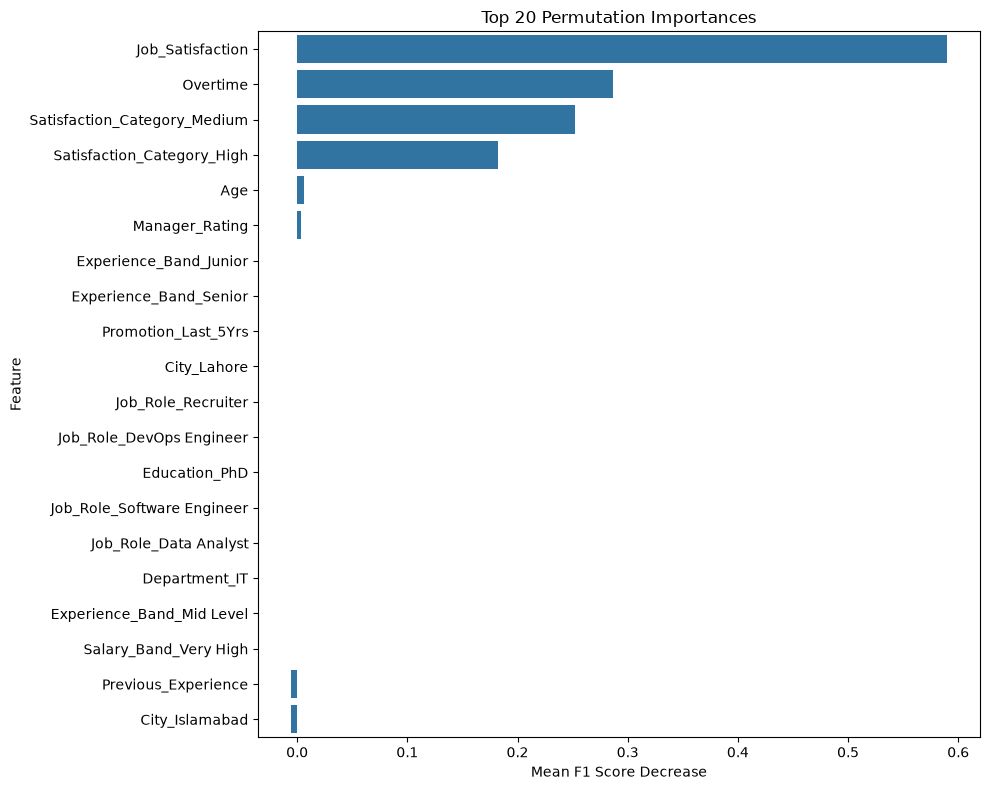

In [14]:
top_permutation = permutation_importance_df.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(data=top_permutation, x="Importance_Mean", y="Feature")

plt.title("Top 20 Permutation Importances")
plt.xlabel("Mean F1 Score Decrease")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [15]:
# Install SHAp
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [16]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


## Create SHAP Explainer

SHAP assigns each feature a contribution value for a model prediction.

In [17]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


## Inspect SHAP Output

In [18]:
print("Type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))

    for i, values in enumerate(shap_values):
        print(f"Class {i} shape:", values.shape)

else:
    print("SHAP shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
SHAP shape: (200, 50, 2)


## Select Attrition SHAP Values

In [19]:
if isinstance(shap_values, list):
    shap_values_attrition = shap_values[1]

else:
    if shap_values.ndim == 3:
        shap_values_attrition = shap_values[:, :, 1]

    else:
        shap_values_attrition = shap_values

print("Attrition SHAP shape:", shap_values_attrition.shape)

Attrition SHAP shape: (200, 50)


## Global SHAP Feature Importance

In [20]:
shap_importance = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Mean_Absolute_SHAP": np.abs(shap_values_attrition).mean(axis=0),
    }
)

shap_importance = shap_importance.sort_values(by="Mean_Absolute_SHAP", ascending=False)

shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
5,Job_Satisfaction,0.089349
46,Satisfaction_Category_Medium,0.042517
6,Overtime,0.035567
47,Satisfaction_Category_High,0.030263
35,City_Karachi,0.004674
14,Years_At_Company,0.004395
9,Training_Hours,0.004242
0,Age,0.003744
17,Workload_Score,0.003736
16,Salary_Per_Experience,0.003359


## Top SHAP Features

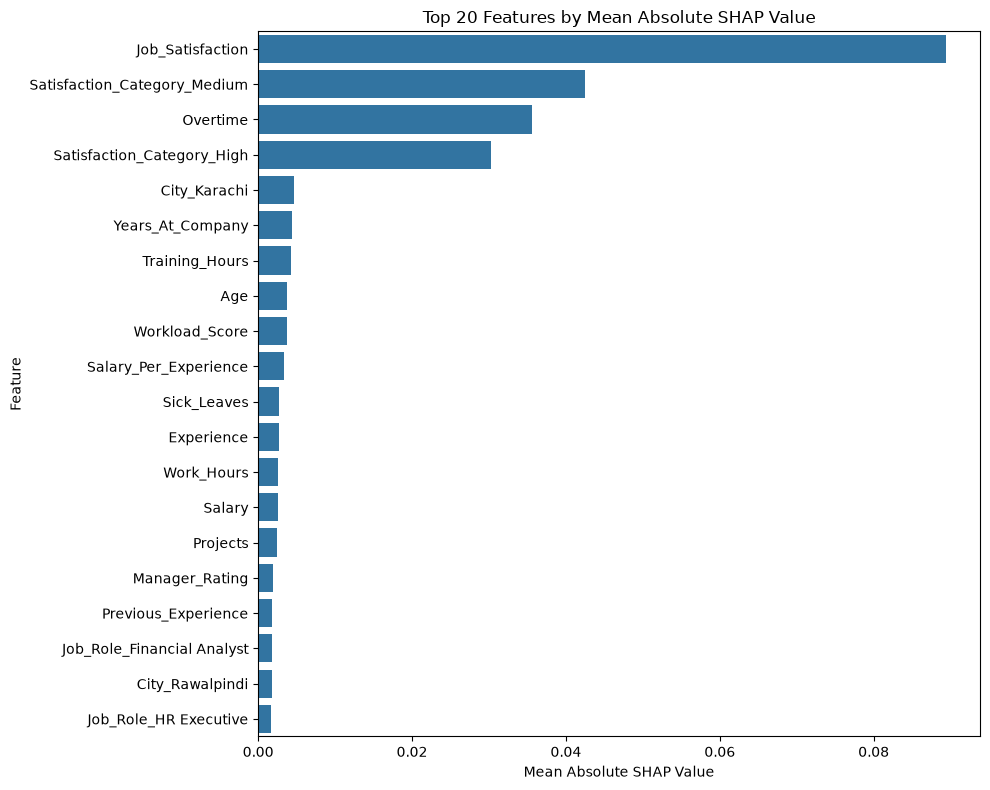

In [21]:
top_shap = shap_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(data=top_shap, x="Mean_Absolute_SHAP", y="Feature")

plt.title("Top 20 Features by Mean Absolute SHAP Value")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## SHAP Summary Plot

The SHAP summary plot shows how each feature affects model predictions across the test dataset.

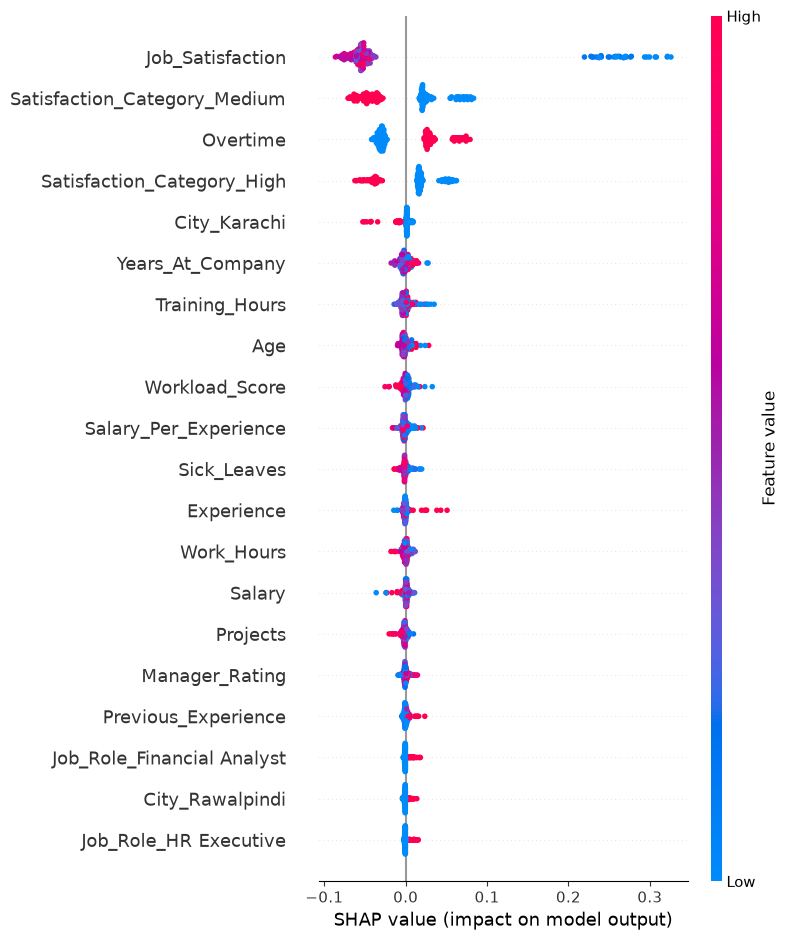

In [22]:
shap.summary_plot(shap_values_attrition, X_test)

## Explain an Individual Employee Prediction

In [23]:
employee_index = 0

employee_data = X_test.iloc[employee_index]

employee_actual = y_test.iloc[employee_index]

employee_prediction = final_model.predict(employee_data.to_frame().T)[0]

employee_probability = final_model.predict_proba(employee_data.to_frame().T)[0, 1]

print("Actual Attrition:", employee_actual)
print("Predicted Attrition:", employee_prediction)
print("Predicted Probability:", round(employee_probability, 4))

Actual Attrition: 0
Predicted Attrition: 0
Predicted Probability: 0.0119


## Employee Feature Values

In [24]:
employee_data

Age                                  60.00
Gender                                1.00
Experience                           15.00
Salary                           216517.00
Performance_Score                     4.00
Job_Satisfaction                      9.00
Overtime                              0.00
Work_Hours                           52.00
Remote_Work                           0.00
Training_Hours                       45.00
Projects                             11.00
Promotion_Last_5Yrs                   0.00
Manager_Rating                        4.00
Sick_Leaves                          13.00
Years_At_Company                     10.30
Previous_Experience                   4.70
Salary_Per_Experience             14434.47
Workload_Score                       16.20
Department_HR                         0.00
Department_IT                         0.00
Department_Marketing                  0.00
Department_Sales                      1.00
Job_Role_Data Analyst                 0.00
Job_Role_De

## Individual SHAP Contributions

In [25]:
employee_shap = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Feature_Value": employee_data.values,
        "SHAP_Value": shap_values_attrition[employee_index],
    }
)

employee_shap["Absolute_SHAP"] = employee_shap["SHAP_Value"].abs()

employee_shap = employee_shap.sort_values(by="Absolute_SHAP", ascending=False)

employee_shap.head(15)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
5,Job_Satisfaction,9.0,-0.045265,0.045265
47,Satisfaction_Category_High,1.0,-0.031532,0.031532
6,Overtime,0.0,-0.027177,0.027177
46,Satisfaction_Category_Medium,0.0,0.017338,0.017338
35,City_Karachi,1.0,-0.007473,0.007473
0,Age,60.0,0.007273,0.007273
17,Workload_Score,16.2,-0.002772,0.002772
9,Training_Hours,45.0,-0.002673,0.002673
10,Projects,11.0,-0.002430,0.002430
49,Performance_Category_High,1.0,0.002348,0.002348


## Factors Increasing or Decreasing Attrition Risk

In [26]:
positive_factors = employee_shap[employee_shap["SHAP_Value"] > 0].head(10)

negative_factors = employee_shap[employee_shap["SHAP_Value"] < 0].head(10)

print("Factors pushing toward attrition:")
print(positive_factors[["Feature", "Feature_Value", "SHAP_Value"]])

print("\nFactors pushing away from attrition:")
print(negative_factors[["Feature", "Feature_Value", "SHAP_Value"]])

Factors pushing toward attrition:
                         Feature  Feature_Value  SHAP_Value
46  Satisfaction_Category_Medium            0.0    0.017338
0                            Age           60.0    0.007273
49     Performance_Category_High            1.0    0.002348
21              Department_Sales            1.0    0.001762
32              Education_Master            0.0    0.000462
33                 Education_PhD            0.0    0.000461
15           Previous_Experience            4.7    0.000429
45        Experience_Band_Senior            1.0    0.000385
3                         Salary       216517.0    0.000245
14              Years_At_Company           10.3    0.000226

Factors pushing away from attrition:
                       Feature  Feature_Value  SHAP_Value
5             Job_Satisfaction            9.0   -0.045265
47  Satisfaction_Category_High            1.0   -0.031532
6                     Overtime            0.0   -0.027177
35                City_Karachi      

## Individual Employee Explanation

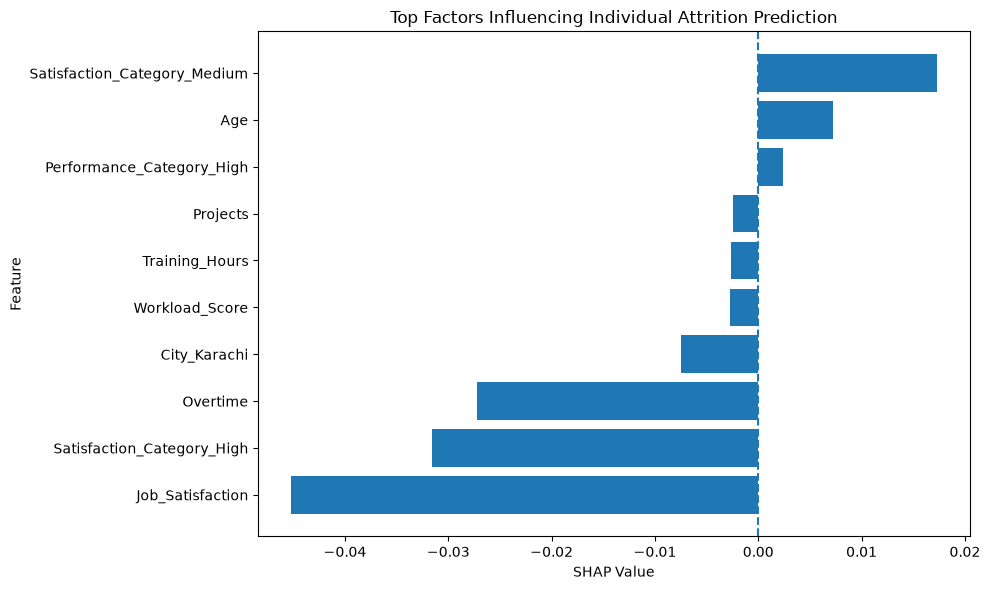

In [27]:
top_employee_factors = employee_shap.head(10).copy()

top_employee_factors = top_employee_factors.sort_values("SHAP_Value")

plt.figure(figsize=(10, 6))

plt.barh(top_employee_factors["Feature"], top_employee_factors["SHAP_Value"])

plt.axvline(0, linestyle="--")

plt.title("Top Factors Influencing Individual Attrition Prediction")

plt.xlabel("SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Business Interpretation

The model should be used to identify employees who may require further review.

Model explanations should be treated as predictive evidence, not proof of causation.

HR decisions should not be based solely on model predictions.

## Employee Risk Category

In [28]:
def risk_category(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.60:
        return "Medium"

    else:
        return "High"


employee_risk = risk_category(employee_probability)

print("Employee Risk Category:", employee_risk)

Employee Risk Category: Low


## Generate Employee Risk Predictions

In [29]:
risk_predictions = X_test.copy()

risk_predictions["Actual_Attrition"] = y_test.values

risk_predictions["Attrition_Probability"] = y_prob

risk_predictions["Predicted_Attrition"] = y_pred

risk_predictions["Risk_Category"] = risk_predictions["Attrition_Probability"].apply(
    risk_category
)

risk_predictions.head()

,Age,Gender,Experience,Salary,Performance_Score,Job_Satisfaction,Overtime,Work_Hours,Remote_Work,Training_Hours,...,Experience_Band_Mid Level,Experience_Band_Senior,Satisfaction_Category_Medium,Satisfaction_Category_High,Performance_Category_Average,Performance_Category_High,Actual_Attrition,Attrition_Probability,Predicted_Attrition,Risk_Category
249,60.0,1,15,216517.0,4,9.0,0,52,0,45,...,0,1,0,1,0,1,0,0.011885,0,Low
632,53.0,1,21,190438.0,2,5.0,1,51,0,21,...,0,1,1,0,0,0,0,0.012295,0,Low
572,41.0,0,10,121415.0,2,6.0,1,41,0,32,...,1,0,1,0,0,0,0,0.039699,0,Low
235,37.0,1,7,145421.0,4,8.0,0,48,1,50,...,1,0,0,1,0,1,0,0.011448,0,Low
276,49.0,1,20,194850.0,1,6.0,0,41,1,64,...,0,1,1,0,0,0,0,0.001684,0,Low


## Highest-Risk Employees

In [30]:
high_risk_employees = risk_predictions.sort_values(
    by="Attrition_Probability", ascending=False
)

high_risk_employees[
    [
        "Attrition_Probability",
        "Predicted_Attrition",
        "Actual_Attrition",
        "Risk_Category",
    ]
].head(10)

,Attrition_Probability,Predicted_Attrition,Actual_Attrition,Risk_Category
89,0.759491,1,1,High
128,0.715927,1,1,High
535,0.702722,1,1,High
328,0.681130,1,1,High
749,0.679116,1,1,High
67,0.654851,1,1,High
621,0.647715,1,0,High
354,0.635739,1,1,High
318,0.634508,1,1,High
315,0.614788,1,1,High


## Employee Risk Distribution

In [31]:
risk_counts = risk_predictions["Risk_Category"].value_counts()

print(risk_counts)

Risk_Category
Low       169
Medium     18
High       13
Name: count, dtype: int64


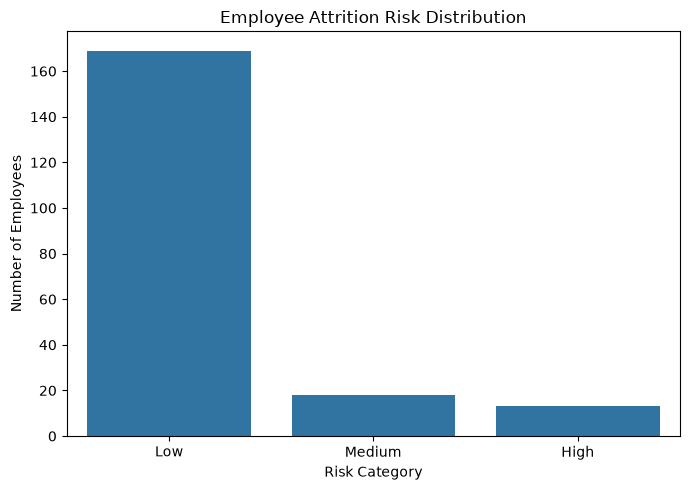

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(data=risk_predictions, x="Risk_Category", order=["Low", "Medium", "High"])

plt.title("Employee Attrition Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

## Save Explainability Results

In [33]:
feature_importance.to_csv("../data/processed/final_feature_importance.csv", index=False)

permutation_importance_df.to_csv(
    "../data/processed/permutation_importance.csv", index=False
)

shap_importance.to_csv("../data/processed/shap_feature_importance.csv", index=False)

risk_predictions.to_csv(
    "../data/processed/employee_attrition_risk_predictions.csv", index=False
)

print("Explainability results saved successfully.")

Explainability results saved successfully.


## Final Model Summary

In [34]:
print("FINAL MODEL")
print("=" * 40)

print("Model: Random Forest")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nTop 10 Features by SHAP Importance:")

print(
    shap_importance.head(10)[["Feature", "Mean_Absolute_SHAP"]].to_string(index=False)
)

FINAL MODEL
Model: Random Forest
Accuracy : 0.9350
Precision: 0.7619
Recall   : 0.6667
F1 Score : 0.7111
ROC-AUC  : 0.9813

Top 10 Features by SHAP Importance:
                     Feature  Mean_Absolute_SHAP
            Job_Satisfaction            0.089349
Satisfaction_Category_Medium            0.042517
                    Overtime            0.035567
  Satisfaction_Category_High            0.030263
                City_Karachi            0.004674
            Years_At_Company            0.004395
              Training_Hours            0.004242
                         Age            0.003744
              Workload_Score            0.003736
       Salary_Per_Experience            0.003359
